In [5]:
import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Plot simulation

In [30]:
simulation_data_path = "test/greedy/c48_p576_h16/simulation.csv"
simulation_data = pd.read_csv(simulation_data_path, index_col=0)
# Exclude the last four columns and select only numeric columns
simulation_data = simulation_data.iloc[:, :-4].select_dtypes(include=[np.number])
simulation_data

,Processor0,Processor1,Processor2,Processor3,Processor4,Processor5,Processor6,Processor7,Processor8,Processor9,...,Processor566,Processor567,Processor568,Processor569,Processor570,Processor571,Processor572,Processor573,Processor574,Processor575
Interval,,,,,,,,,,,,,,,,,,,,,
0,4094.0,3999.0,4024.0,4132.0,4159.0,3801.0,4119.0,4337.0,4329.0,4093.0,...,3698.0,3522.0,3766.0,3631.0,3449.0,3734.0,3757.0,3813.0,3610.0,3739.0
1,3636.0,3564.0,3714.0,3848.0,3820.0,3722.0,3734.0,3688.0,3827.0,3657.0,...,3588.0,3285.0,3581.0,3538.0,3372.0,3549.0,3445.0,3642.0,3426.0,3457.0
2,3438.0,3382.0,3512.0,3713.0,3689.0,3513.0,3439.0,3504.0,3734.0,3446.0,...,3346.0,3152.0,3364.0,3280.0,3272.0,3308.0,3291.0,3292.0,3265.0,3279.0
3,3425.0,3345.0,3458.0,3620.0,3642.0,3486.0,3339.0,3442.0,3723.0,3443.0,...,3301.0,3104.0,3353.0,3264.0,3201.0,3400.0,3239.0,3274.0,3220.0,3242.0
4,3403.0,3390.0,3410.0,3640.0,3651.0,3337.0,3341.0,3315.0,3569.0,3426.0,...,3239.0,3094.0,3296.0,3262.0,3243.0,3349.0,3284.0,3276.0,3184.0,3237.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,3873.0,4176.0,4043.0,3828.0,3808.0,4005.0,3978.0,4195.0,3883.0,3881.0,...,3141.0,3660.0,3546.0,3656.0,3423.0,3270.0,3320.0,3584.0,3508.0,3532.0
68,3868.0,4232.0,3967.0,3702.0,3761.0,3971.0,3975.0,4213.0,3891.0,3724.0,...,3140.0,3618.0,3417.0,3585.0,3454.0,3236.0,3333.0,3535.0,3539.0,3420.0
69,3782.0,4108.0,3945.0,3631.0,3675.0,3910.0,3972.0,4185.0,3757.0,3675.0,...,3104.0,3465.0,3319.0,3537.0,3417.0,3212.0,3272.0,3519.0,3505.0,3416.0


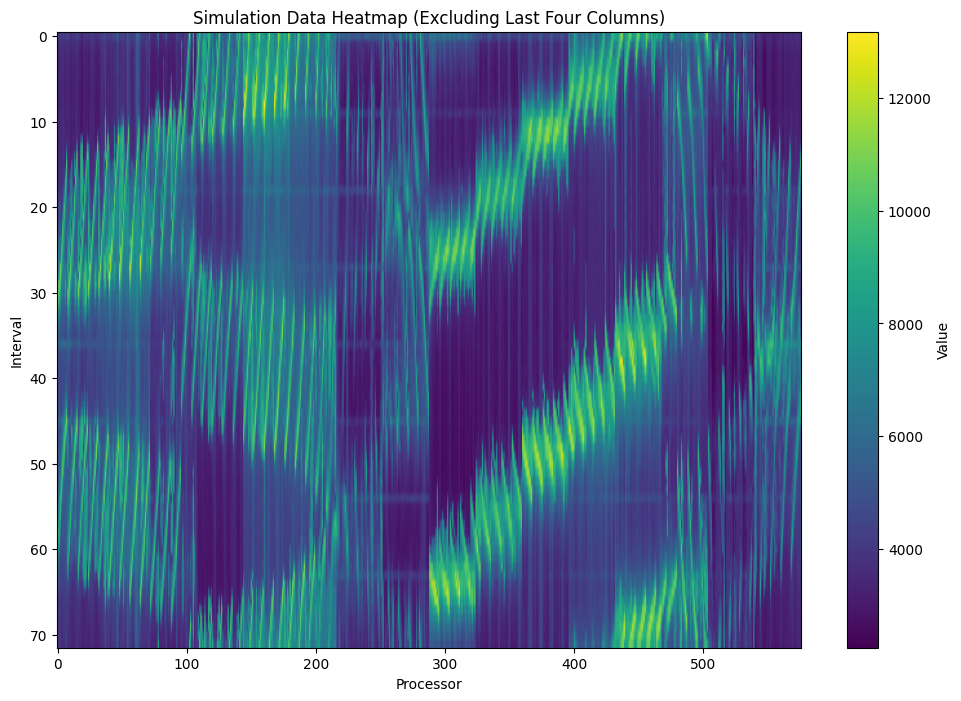

In [34]:
# Plot the simulation data as a heatmap, excluding the last four columns
def plot_simulation_heatmap(data: pd.DataFrame, path: Optional[str] = None):
    plt.figure(figsize=(12, 8))
    # vmin = 0
    # vmax = np.nanpercentile(data.values, 99)
    # cax = plt.imshow(data, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    cax = plt.imshow(data, aspect="auto", cmap="viridis")
    plt.colorbar(cax, label="Value")
    plt.xlabel("Processor")
    plt.ylabel("Interval")
    plt.title("Simulation Data Heatmap (Excluding Last Four Columns)")
    if path:
        os.makedirs(path, exist_ok=True)
        plt.savefig(f"{path}/simulation_heatmap.png")
        plt.savefig(f"{path}/simulation_heatmap.eps")
    plt.show()


# Assuming simulation_data is already loaded as a DataFrame
# Plot the simulation data heatmap
plot_simulation_heatmap(simulation_data, path="test/plots/greedy/c48_p576")

Generate random grouping

In [29]:
num_hosts = 16
processors_per_host = 36
processors = num_hosts * processors_per_host

seed = 0
indices = np.arange(processors)
if seed:
    np.random.seed(seed)  # Set seed for the group to be same across parallel runs
    np.random.shuffle(indices)
processor_groups = [
    list(indices[i * processors_per_host : (i + 1) * processors_per_host])
    for i in range(num_hosts)
]
node_df = pd.DataFrame(processor_groups)
node_df

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
1,36,37,38,39,40,41,42,43,44,45,...,62,63,64,65,66,67,68,69,70,71
2,72,73,74,75,76,77,78,79,80,81,...,98,99,100,101,102,103,104,105,106,107
3,108,109,110,111,112,113,114,115,116,117,...,134,135,136,137,138,139,140,141,142,143
4,144,145,146,147,148,149,150,151,152,153,...,170,171,172,173,174,175,176,177,178,179
5,180,181,182,183,184,185,186,187,188,189,...,206,207,208,209,210,211,212,213,214,215
6,216,217,218,219,220,221,222,223,224,225,...,242,243,244,245,246,247,248,249,250,251
7,252,253,254,255,256,257,258,259,260,261,...,278,279,280,281,282,283,284,285,286,287
8,288,289,290,291,292,293,294,295,296,297,...,314,315,316,317,318,319,320,321,322,323
9,324,325,326,327,328,329,330,331,332,333,...,350,351,352,353,354,355,356,357,358,359


Plot group's total simulated workload

In [27]:
dynamic_node_mapping = {}
for group_id, row in node_df.iterrows():
    for processor_id in row:
        dynamic_node_mapping[f"Processor{processor_id}"] = f"Group{group_id}"
print(dynamic_node_mapping)

{'Processor0': 'Group0', 'Processor1': 'Group0', 'Processor2': 'Group0', 'Processor3': 'Group0', 'Processor4': 'Group0', 'Processor5': 'Group0', 'Processor6': 'Group0', 'Processor7': 'Group0', 'Processor8': 'Group0', 'Processor9': 'Group0', 'Processor10': 'Group0', 'Processor11': 'Group0', 'Processor12': 'Group0', 'Processor13': 'Group0', 'Processor14': 'Group0', 'Processor15': 'Group0', 'Processor16': 'Group0', 'Processor17': 'Group0', 'Processor18': 'Group0', 'Processor19': 'Group0', 'Processor20': 'Group0', 'Processor21': 'Group0', 'Processor22': 'Group0', 'Processor23': 'Group0', 'Processor24': 'Group0', 'Processor25': 'Group0', 'Processor26': 'Group0', 'Processor27': 'Group0', 'Processor28': 'Group0', 'Processor29': 'Group0', 'Processor30': 'Group0', 'Processor31': 'Group0', 'Processor32': 'Group0', 'Processor33': 'Group0', 'Processor34': 'Group0', 'Processor35': 'Group0', 'Processor36': 'Group1', 'Processor37': 'Group1', 'Processor38': 'Group1', 'Processor39': 'Group1', 'Processo

In [31]:
# Rename columns in workload_df using the dynamic node mapping
dynamic_grouped_df = simulation_data.rename(columns=dynamic_node_mapping)
# Sum workload by group
dynamic_summed_df = dynamic_grouped_df.T.groupby(level=0).sum().T
dynamic_summed_df

,Group0,Group1,Group10,Group11,Group12,Group13,Group14,Group15,Group2,Group3,Group4,Group5,Group6,Group7,Group8,Group9
Interval,,,,,,,,,,,,,,,,
0,143318.0,162639.0,165063.0,249928.0,321384.0,260995.0,190237.0,125969.0,156167.0,258653.0,313506.0,276912.0,196180.0,213325.0,218671.0,164673.0
1,129865.0,146415.0,139634.0,259000.0,279747.0,219415.0,184543.0,119019.0,146026.0,256338.0,300539.0,262646.0,145325.0,179705.0,174828.0,129280.0
2,123228.0,141158.0,137129.0,279327.0,247804.0,206570.0,184775.0,112294.0,139032.0,256342.0,307817.0,258778.0,137768.0,172634.0,160787.0,121386.0
3,121470.0,139266.0,137555.0,300479.0,221385.0,205476.0,181854.0,111119.0,137505.0,259135.0,315615.0,258961.0,134820.0,168444.0,152022.0,117110.0
4,119782.0,139094.0,144575.0,317071.0,199715.0,210617.0,177220.0,110395.0,136850.0,261101.0,322353.0,258831.0,134110.0,165702.0,141737.0,116042.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,134780.0,169364.0,133282.0,161796.0,327159.0,287973.0,161146.0,119374.0,180851.0,179863.0,252065.0,272758.0,161502.0,161110.0,287825.0,138558.0
68,132231.0,158951.0,132221.0,168143.0,351720.0,271392.0,162121.0,116966.0,165864.0,202756.0,259986.0,272692.0,154909.0,169252.0,248597.0,131618.0
69,130578.0,155225.0,131999.0,177888.0,361756.0,255519.0,161972.0,115706.0,152651.0,217172.0,267175.0,273016.0,150496.0,172533.0,217563.0,126969.0


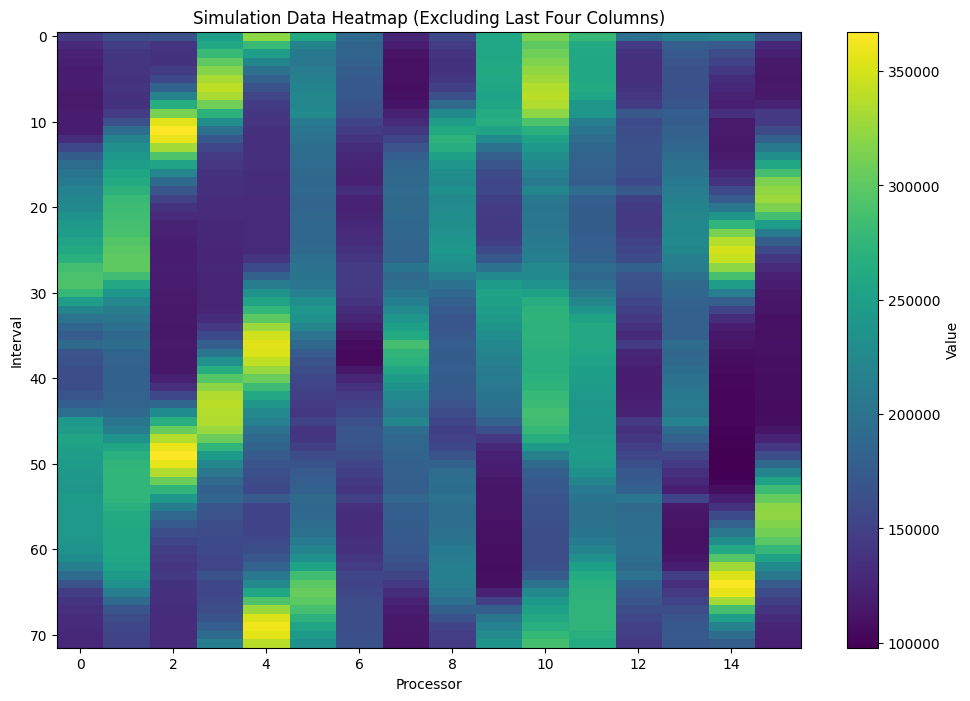

In [35]:
plot_simulation_heatmap(dynamic_summed_df, path="test/plots/greedy/c48_p576_h16")